In [1]:
import torch
import torch.nn.functional as F
import clip
from PIL import Image
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# TESTING_FOLDER = Path.home() / Path("Desktop/testing")
TESTING_FOLDER = Path("testing/")
METADATA_PATH = TESTING_FOLDER / "metadata.xlsx"

In [3]:
df = pd.read_excel(METADATA_PATH)
id_map = {row.Path: i for i, row in enumerate(df.itertuples(index=False))}
df["id"] = df["Path"].map(id_map)
df

,Path,Description,id
0,1.jpg,Screenshot of a meme showing an orange cat cov...,0
1,2.jpg,A photograph of a dog curled up lying on its d...,1
2,3.jpg,An image of a tree-shaped antenna mounted outd...,2
3,4.jpg,A meme image featuring a cat with wide terrifi...,3
4,5.jpg,A cartoon drawing of a dog with a thought bubb...,4
5,6.jpg,A two-panel comic strip showing a woman saying...,5
6,7.jpg,An image of a masked man wearing a t-shirt wit...,6
7,8.jpg,A screenshot of a tweet containing a line grap...,7
8,9.jpg,"The classic ""are you winning, son?"" meme showi...",8
9,10.jpg,A social media post about computer safety or c...,9


In [4]:
TOP_K = 4

In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)

In [6]:
image_embeddings = []
valid_rows = []

for row in df.itertuples(index=False):

    if not row.Path.lower().endswith(".jpg"):
        continue

    image_path = TESTING_FOLDER / row.Path

    image = preprocess(Image.open(image_path).convert("RGB")).unsqueeze(0).to(device)

    with torch.no_grad():
        embedding = model.encode_image(image)
        embedding = F.normalize(embedding, dim=-1)

    image_embeddings.append(embedding.cpu())
    valid_rows.append(row)

image_embeddings = torch.cat(image_embeddings, dim=0)

In [7]:
def reciprocal_rank(results, correct_id):
    try:
        rank = results.index(correct_id) + 1
        return 1 / rank
    except ValueError:
        return 0.0
    
def hit_at_k(results, correct_id, k):
    return int(correct_id in results[:k])

In [8]:
TOP_K = 4

N = len(df)

hit_matrices = {
    k: pd.DataFrame(
        0,
        index=range(N),
        columns=range(N),
        dtype=int
    )
    for k in range(1, TOP_K + 1)
}

In [9]:
for row in df.itertuples(index=False):
    if not row.Path.lower().endswith(".jpg"):
        continue

    current_query = row.Description
    text = clip.tokenize([current_query]).to(device)

    with torch.no_grad():
        text_embedding = model.encode_text(text)
        text_embedding = F.normalize(text_embedding, dim=-1)

    scores = (text_embedding.cpu() @ image_embeddings.T).squeeze(0)
    values, indices = torch.topk(scores, TOP_K)


    ground_truth = row

    print("=" * 120)
    print(f"QUERY (real description): {current_query}")
    print(f"GROUND TRUTH PATH: {ground_truth.Path}")
    print(f"GROUND TRUTH ID: {ground_truth.id}")
    print()
    print("TOP RESULTS:\n")

    retrieved_ids = []

    for rank, (score, idx) in enumerate(zip(values, indices), start=1):
        guess_row = valid_rows[idx.item()]
        retrieved_ids.append(guess_row.id)

        print(f"Rank {rank}")
        print(f"Path: {guess_row.Path}")
        print(f"DB Description: {guess_row.Description}")
        print(f"Score: {score.item():.6f}")
        print(f"Mapped ID: {guess_row.id}")
    
        for k in range(1, TOP_K + 1):
            if ground_truth.id in retrieved_ids[:k]:
                hit_matrices[k].loc[ground_truth.id, ground_truth.id] = 1

    hit1 = hit_at_k(retrieved_ids, ground_truth.id, 1)
    print(f"\nHIT@1: {hit1}")
    

QUERY (real description): Screenshot of a meme showing an orange cat covering its face with one paw. An emoji below the cat mimics the same embarrassed facial expression.
GROUND TRUTH PATH: 1.jpg
GROUND TRUTH ID: 0

TOP RESULTS:

Rank 1
Path: 1.jpg
DB Description: Screenshot of a meme showing an orange cat covering its face with one paw. An emoji below the cat mimics the same embarrassed facial expression.
Score: 0.308821
Mapped ID: 0
Rank 2
Path: 4.jpg
DB Description: A meme image featuring a cat with wide terrified eyes and a panicked expression, with a matching frightened emoji displayed directly below it.
Score: 0.303973
Mapped ID: 3
Rank 3
Path: 20.jpg
DB Description: A programming humor meme featuring two cats: one calmly writing C code while the other is shown stressed out being forced to produce web applications.
Score: 0.258947
Mapped ID: 19
Rank 4
Path: 14.jpg
DB Description: A social media post featuring two cats that appear to be staring blankly or acting foolish, presented

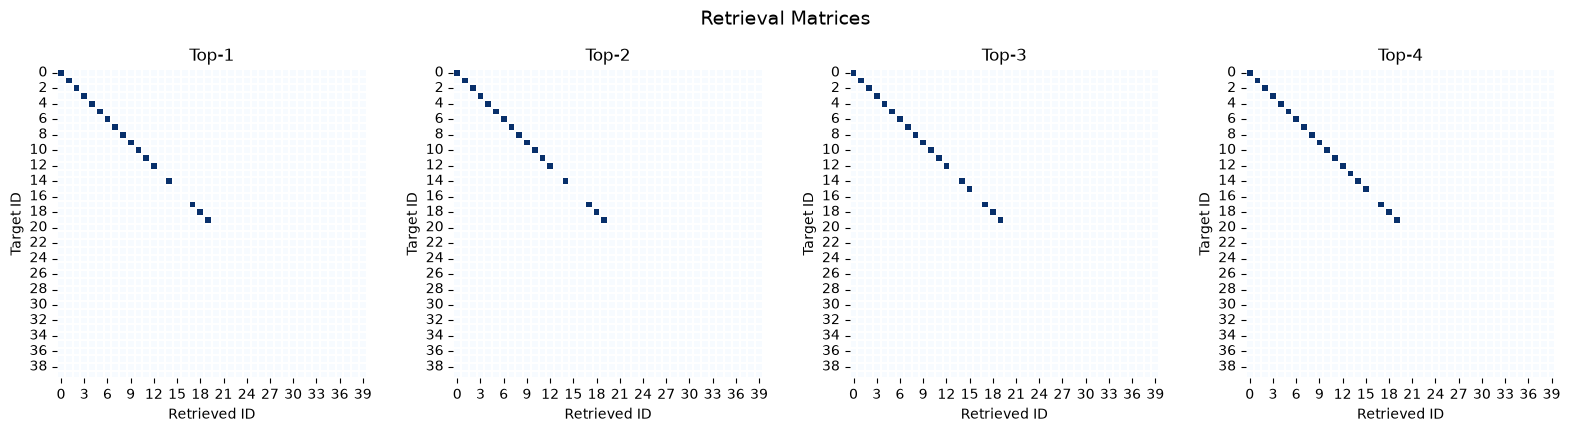

In [10]:
import math

fig_cols = TOP_K
fig_rows = math.ceil(len(hit_matrices) / fig_cols)

fig, axes = plt.subplots(fig_rows, fig_cols, figsize=(fig_cols * 4, fig_rows * 4))
axes = axes.flatten()

for idx, (k, matrix) in enumerate(hit_matrices.items()):
    sns.heatmap(
        matrix,
        ax=axes[idx],
        cmap="Blues",
        square=True,
        cbar=False,
        linewidths=0.2,
    )
    axes[idx].set_title(f"Top-{k}")
    axes[idx].set_xlabel("Retrieved ID")
    axes[idx].set_ylabel("Target ID")

for idx in range(len(hit_matrices), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle("Retrieval Matrices", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()